UAS Model Deployment  
Jocellyn Jonathan - 2802392085 - LA09

Link Video: https://drive.google.com/drive/folders/1VVCqIKT8mxYab8zT0IgVdoiu4ExxNa_c?usp=sharing 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

## 1. Data Understanding

In [2]:
df = pd.read_csv('data_B.csv')
df.head()

,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0x15309,CUS_0xaa66,April,NaN,32,841-06-2917,Architect,14995.29,NaN,...,Bad,4593.28,29.968714,3 Years and 2 Months,Yes,60.535964,54.73854091370111,Low_spent_Medium_value_payments,278.586245369556,Poor
1,1,0x8bb6,CUS_0x7d83,January,Dasguptaj,30,227-93-6471,Lawyer,74902.8,6272.900000,...,Bad,2900.49,28.086006,12 Years and 9 Months,Yes,534.751534,52.25901203477476,High_spent_Large_value_payments,280.27945391259857,Poor
2,2,0xe016,CUS_0x71aa,January,Nicholasq,22,632-01-7252,Lawyer,20574.71,1813.559167,...,Bad,2592.78,32.525087,12 Years and 1 Months,Yes,88.759975,77.89308197841973,Low_spent_Large_value_payments,284.70286002007293,Poor
3,3,0xbffb,CUS_0x59b6,February,Scuffhamk,53,315-03-3600,Writer,111090.06,9192.505000,...,Good,575.32,25.360743,27 Years and 6 Months,No,149.079658,436.7372848909153,Low_spent_Medium_value_payments,613.4335567793378,Standard
4,4,0xa96e,CUS_0x36a1,January,Miyoung Kimh,42,286-88-7128,Teacher,19214.965,1730.247083,...,Good,498.81,37.600265,28 Years and 9 Months,No,0.000000,217.7804724472987,!@9#%8,245.2442358860347,Good


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                25000 non-null  int64  
 1   ID                        25000 non-null  object 
 2   Customer_ID               25000 non-null  object 
 3   Month                     25000 non-null  object 
 4   Name                      22534 non-null  object 
 5   Age                       25000 non-null  object 
 6   SSN                       25000 non-null  object 
 7   Occupation                25000 non-null  object 
 8   Annual_Income             25000 non-null  object 
 9   Monthly_Inhand_Salary     21244 non-null  float64
 10  Num_Bank_Accounts         25000 non-null  int64  
 11  Num_Credit_Card           25000 non-null  int64  
 12  Interest_Rate             25000 non-null  int64  
 13  Num_of_Loan               25000 non-null  object 
 14  Type_o

In [4]:
df.describe()

,Unnamed: 0,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,25000.000000,21244.000000,25000.000000,25000.000000,25000.000000,25000.000000,24510.000000,25000.000000,25000.000000
mean,12499.500000,4202.920107,16.189320,22.204800,72.883720,21.029360,27.477111,32.294362,1300.578910
std,7217.022701,3167.562787,113.979946,128.635884,464.533619,14.815959,191.841035,5.136061,7938.267492
min,0.000000,303.645417,-1.000000,0.000000,1.000000,-5.000000,0.000000,20.257073,0.000000
25%,6249.750000,1634.214792,3.000000,4.000000,8.000000,10.000000,3.000000,28.007510,30.622965
50%,12499.500000,3118.399167,6.000000,5.000000,13.000000,18.000000,6.000000,32.276799,69.528976
75%,18749.250000,5968.797083,7.000000,7.000000,20.000000,28.000000,9.000000,36.553116,161.078485
max,24999.000000,15204.633333,1798.000000,1495.000000,5774.000000,67.000000,2587.000000,49.254983,82256.000000


## 2. Data Cleaning

### 2.1 Drop Kolom yang Tidak Relevan

In [5]:
df = df.drop(columns=['Unnamed: 0', 'ID', 'Customer_ID', 'Name', 'SSN'])
df.columns

Index(['Month', 'Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Type_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment',
       'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix',
       'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

### 2.2 Sesuaikan tipe data

In [6]:
numeric_cols = [
    'Age',
    'Annual_Income',
    'Num_of_Loan',
    'Num_of_Delayed_Payment',
    'Changed_Credit_Limit',
    'Outstanding_Debt',
    'Amount_invested_monthly',
    'Monthly_Balance'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace('_', '', regex=False), errors='coerce')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     25000 non-null  object 
 1   Age                       25000 non-null  int64  
 2   Occupation                25000 non-null  object 
 3   Annual_Income             25000 non-null  float64
 4   Monthly_Inhand_Salary     21244 non-null  float64
 5   Num_Bank_Accounts         25000 non-null  int64  
 6   Num_Credit_Card           25000 non-null  int64  
 7   Interest_Rate             25000 non-null  int64  
 8   Num_of_Loan               25000 non-null  int64  
 9   Type_of_Loan              22152 non-null  object 
 10  Delay_from_due_date       25000 non-null  int64  
 11  Num_of_Delayed_Payment    23267 non-null  float64
 12  Changed_Credit_Limit      24468 non-null  float64
 13  Num_Credit_Inquiries      24510 non-null  float64
 14  Credit

### 2.3 Cek missing value

In [8]:
df.isna().sum()

Month                          0
Age                            0
Occupation                     0
Annual_Income                  0
Monthly_Inhand_Salary       3756
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Type_of_Loan                2848
Delay_from_due_date            0
Num_of_Delayed_Payment      1733
Changed_Credit_Limit         532
Num_Credit_Inquiries         490
Credit_Mix                     0
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Credit_History_Age          2292
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly     1060
Payment_Behaviour              0
Monthly_Balance              301
Credit_Score                   0
dtype: int64

Sebagian besar fitur tidak memiliki missing values. Missing values hanya ditemukan pada beberapa kolom, dengan jumlah terbanyak pada Monthly_Inhand_Salary, Type_of_Loan, Credit_History_Age, dimana pada masing-masing kolom tersebut terdapat lebih dari 2000 missing values.

### 2.4 Cek duplikat

In [9]:
df.duplicated().sum()

0

### 2.5 Cek Inkonsistensi

In [10]:
cat_cols = df.select_dtypes(include=["object"]).columns
for col in cat_cols:
    print(df[col].value_counts(dropna=False), "\n")

Month
March       3184
July        3175
January     3137
August      3136
April       3122
February    3106
May         3082
June        3058
Name: count, dtype: int64 

Occupation
_______          1792
Lawyer           1634
Scientist        1608
Accountant       1592
Engineer         1572
Architect        1570
Mechanic         1562
Writer           1559
Entrepreneur     1554
Media_Manager    1551
Developer        1511
Doctor           1509
Journalist       1508
Teacher          1498
Manager          1491
Musician         1489
Name: count, dtype: int64 

Type_of_Loan
NaN                                                                                2848
Not Specified                                                                       367
Student Loan                                                                        317
Credit-Builder Loan                                                                 315
Personal Loan                                                             

### 2.6 Handle Inkonsistensi

In [11]:
def clean_categorical(df):
    df = df.copy()
    df.replace({
        "_": np.nan,
        "_______": np.nan,
        "!@9#%8": np.nan
    }, inplace=True)

    return df

df[cat_cols] = clean_categorical(df[cat_cols])

In [12]:
# Pada kolom Payment_of_Min_Amount, 'NM' dianggap sebagai kesalahan penulisan dan diubah menjadi 'No'
df['Payment_of_Min_Amount'] = (
    df['Payment_of_Min_Amount']
    .replace({'NM': 'No'})
)

In [13]:
def clean_loan(x):
    if pd.isna(x):
        return np.nan

    x = x.replace(', and ', ', ')
    loans = [loan.strip() for loan in x.split(',')]
    loans = list(dict.fromkeys(loans))
    return ', '.join(loans)

df['Type_of_Loan'] = df['Type_of_Loan'].apply(clean_loan)
df['Type_of_Loan'].head(10)

0    Auto Loan, Payday Loan, Mortgage Loan, Student...
1    Auto Loan, Debt Consolidation Loan, Not Specif...
2    Mortgage Loan, Home Equity Loan, Payday Loan, ...
3          Payday Loan, Credit-Builder Loan, Auto Loan
4                                                  NaN
5                                  Credit-Builder Loan
6                                        Mortgage Loan
7                                                  NaN
8    Payday Loan, Not Specified, Debt Consolidation...
9    Not Specified, Credit-Builder Loan, Debt Conso...
Name: Type_of_Loan, dtype: object

Cek Kembali

In [14]:
for col in cat_cols:
    print(df[col].value_counts(dropna=False), "\n")

Month
March       3184
July        3175
January     3137
August      3136
April       3122
February    3106
May         3082
June        3058
Name: count, dtype: int64 

Occupation
NaN              1792
Lawyer           1634
Scientist        1608
Accountant       1592
Engineer         1572
Architect        1570
Mechanic         1562
Writer           1559
Entrepreneur     1554
Media_Manager    1551
Developer        1511
Doctor           1509
Journalist       1508
Teacher          1498
Manager          1491
Musician         1489
Name: count, dtype: int64 

Type_of_Loan
NaN                                                                                        2848
Not Specified                                                                               402
Student Loan                                                                                377
Personal Loan                                                                               360
Credit-Builder Loan                       

## 3. Exploratory Data Analysis

### 3.1 Cek distribusi target

Credit_Score
Standard    13257
Poor         7197
Good         4546
Name: count, dtype: int64


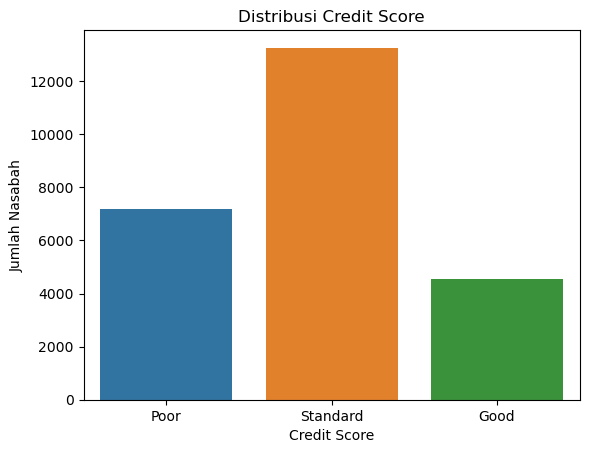

In [15]:
counts = df['Credit_Score'].value_counts()
print(counts)

sns.countplot(x='Credit_Score', data=df, hue='Credit_Score')
plt.title('Distribusi Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Jumlah Nasabah')
plt.show()

Distribusi target menunjukkan bahwa kelas Standard memiliki jumlah data paling banyak, diikuti oleh Poor dan Good. Ketidakseimbangan kelas tidak terlalu ekstrem, namun tetap perlu diperhatikan dalam proses evaluasi model. Oleh karena itu, selain Accuracy digunakan juga metrik Precision, Recall, dan F1-Score untuk memastikan performa model pada seluruh kelas dapat dievaluasi secara lebih komprehensif.

### 3.2 Cek Korelasi

In [16]:
cat_cols = df.select_dtypes(include='object').drop(columns=['Credit_Score', 'Type_of_Loan', 'Credit_History_Age']).columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

#### 3.2.1 Kolom kategorikal vs Credit Score

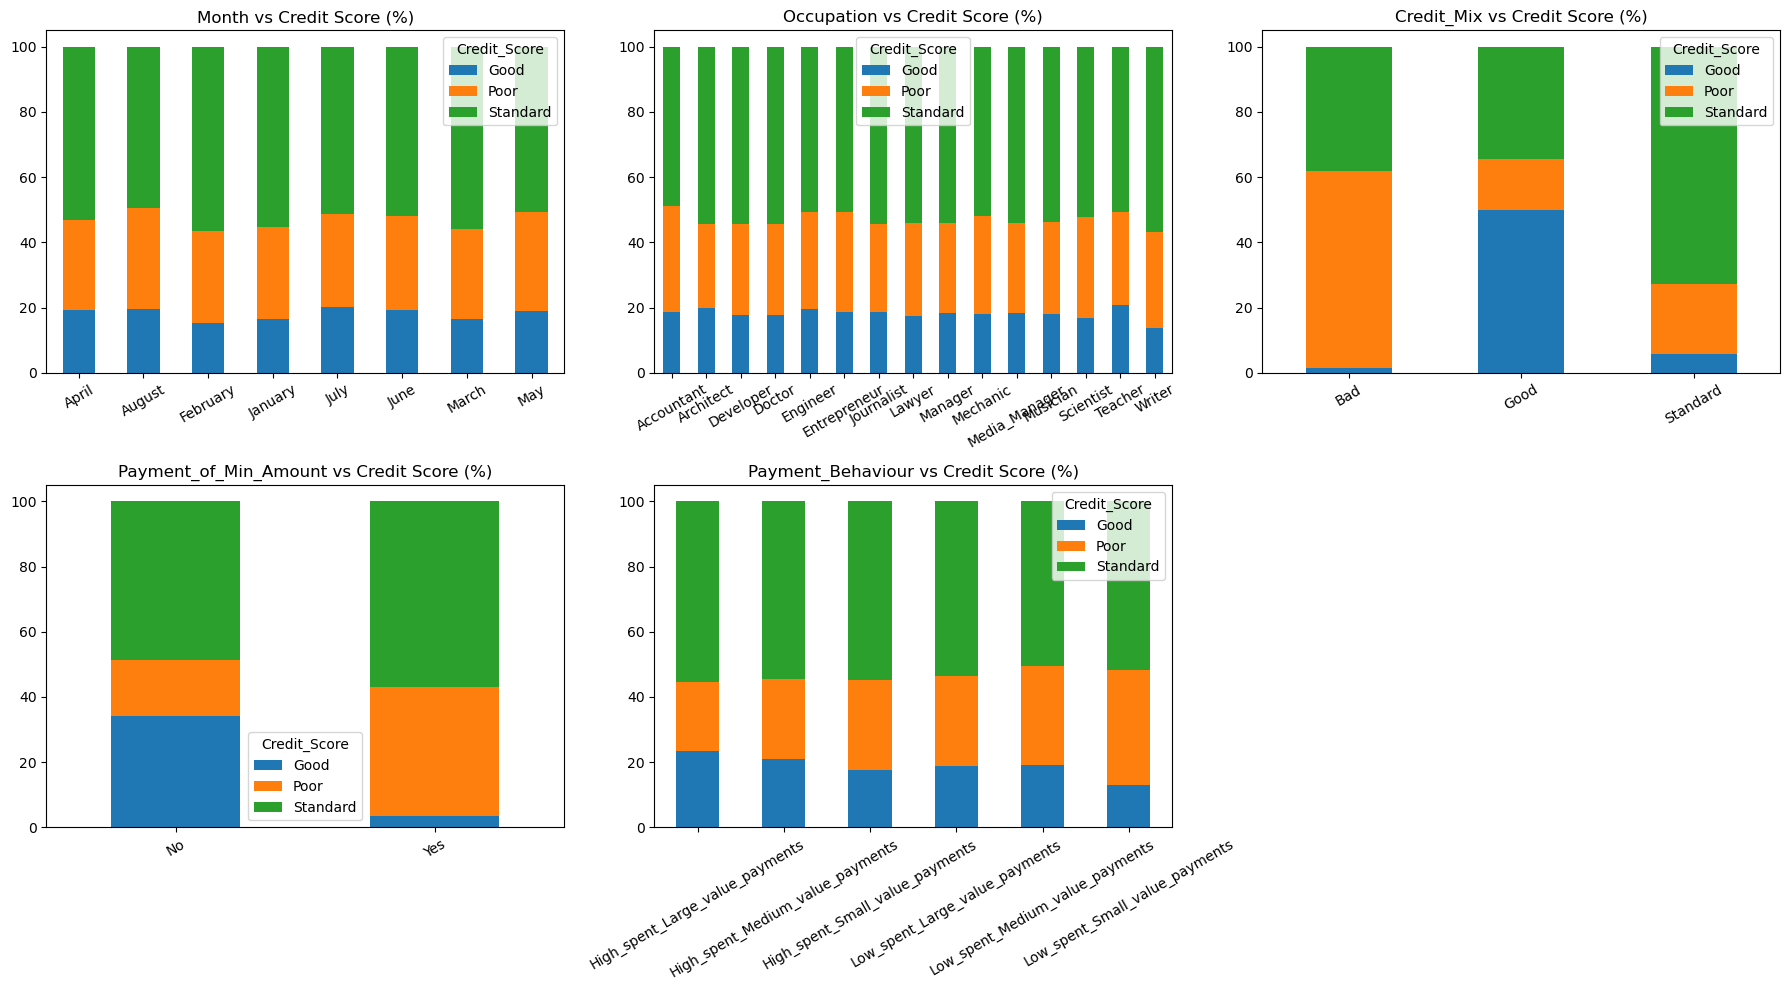

In [17]:
n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['Credit_Score'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i])
    axes[i].set_title(f'{col} vs Credit Score (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Berdasarkan plot tersebut, terlihat bahwa Credit Mix dan Payment of Minimum Amount memiliki pola yang paling jelas dalam membedakan kategori credit score. Nasabah dengan Credit Mix Good memiliki proporsi credit score Good yang jauh lebih tinggi dibandingkan kategori lainnya, sedangkan Credit Mix Bad didominasi oleh credit score Poor. Selain itu, nasabah yang tidak hanya membayar minimum tagihan (No) memiliki proporsi credit score Good yang lebih besar dibandingkan nasabah yang hanya membayar minimum tagihan (Yes). Sebaliknya, fitur lainnya menunjukkan distribusi credit score yang relatif serupa pada setiap kategori sehingga pengaruhnya terhadap credit score cenderung lebih kecil. 

#### 3.2.2 Kolom numerik vs Credit Score

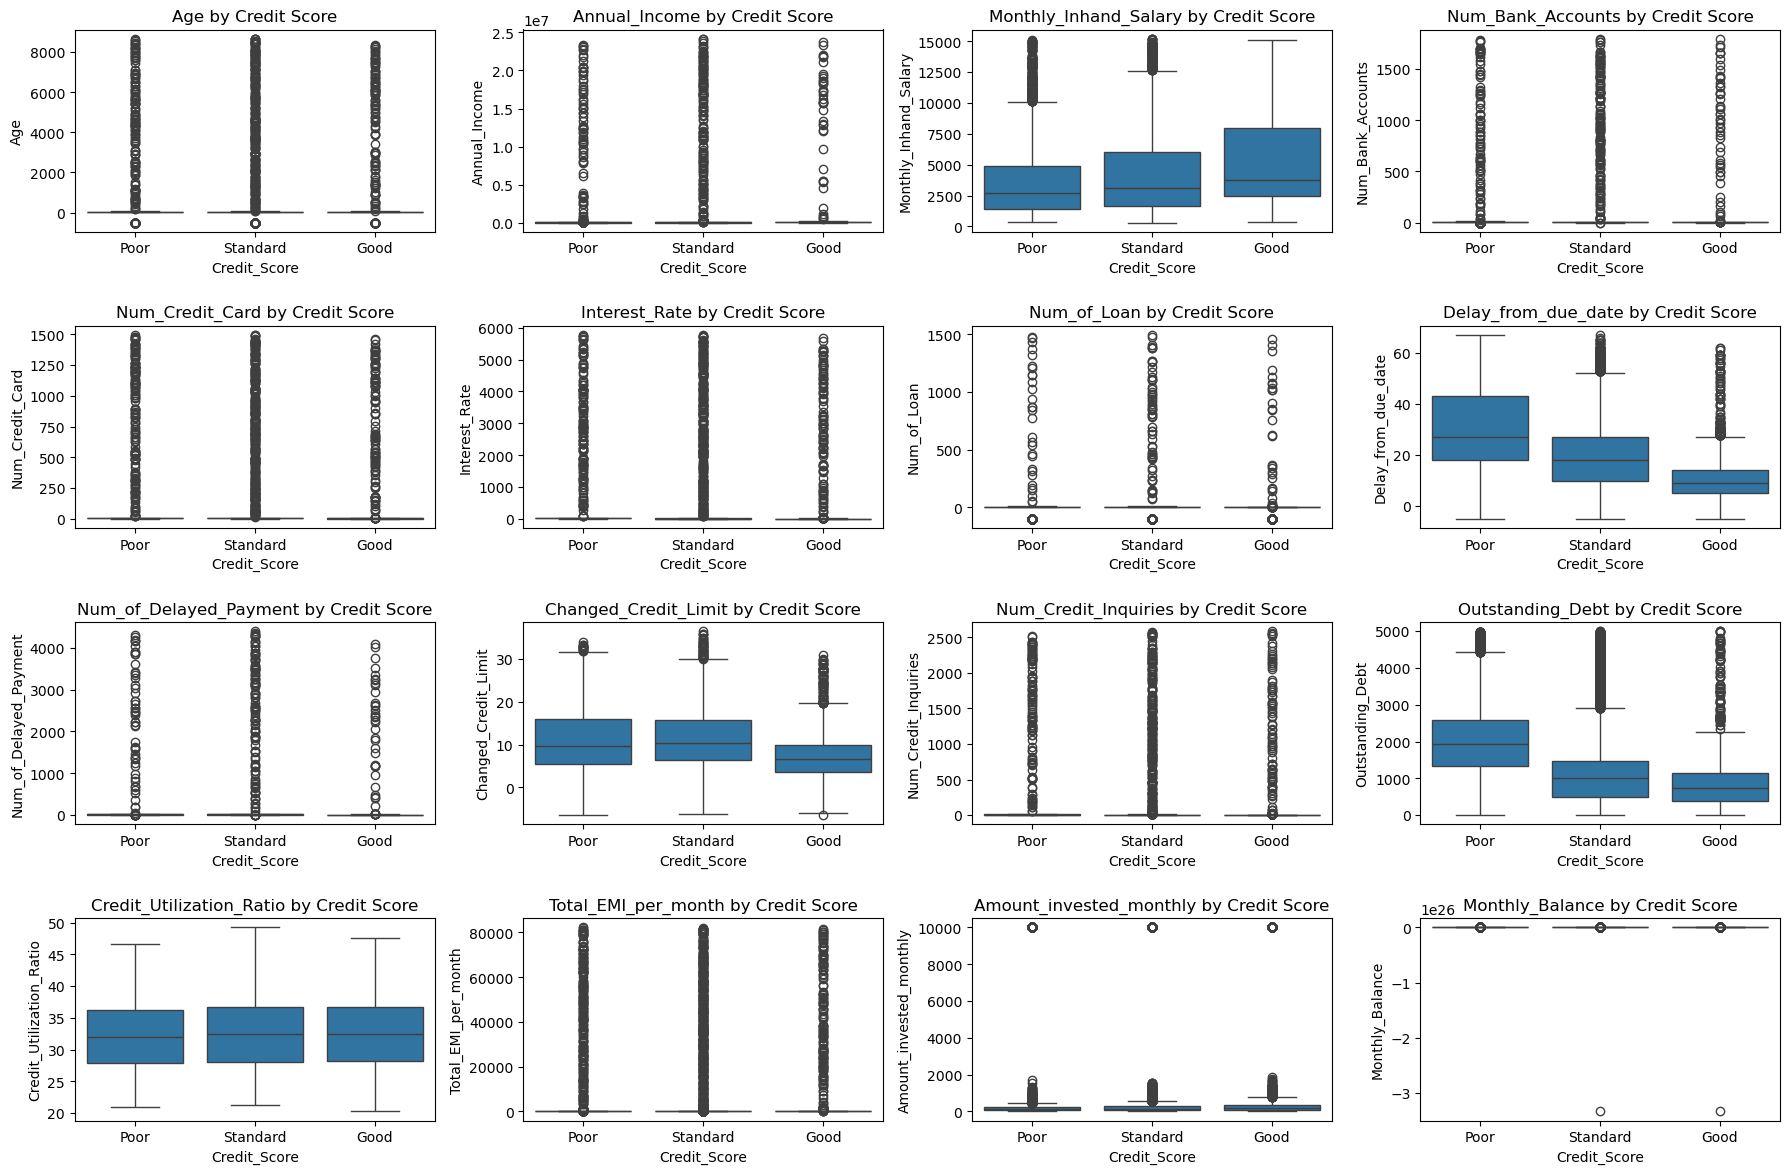

In [18]:
fig, axes = plt.subplots(4, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='Credit_Score', y=col, ax=axes[i])
    axes[i].set_title(f'{col} by Credit Score')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Berdasarkan plot tersebut, beberapa fitur menunjukkan perbedaan distribusi yang cukup jelas antar kelas. Nasabah dengan credit score Good cenderung memiliki Monthly Inhand Salary yang lebih tinggi, Outstanding Debt yang lebih rendah, serta Delay from Due Date yang lebih kecil dibandingkan kelas Poor dan Standard. Sebaliknya, nasabah dengan credit score Poor umumnya memiliki tingkat utang yang lebih tinggi, keterlambatan pembayaran yang lebih sering, dan tingkat bunga yang lebih besar. Visualisasi juga memperlihatkan banyak outlier pada sejumlah fitur, sehingga proses penanganan nilai ekstrem menjadi penting agar model dapat menangkap pola yang lebih representatif dari data.

#### 3.2.3 Outlier Analysis

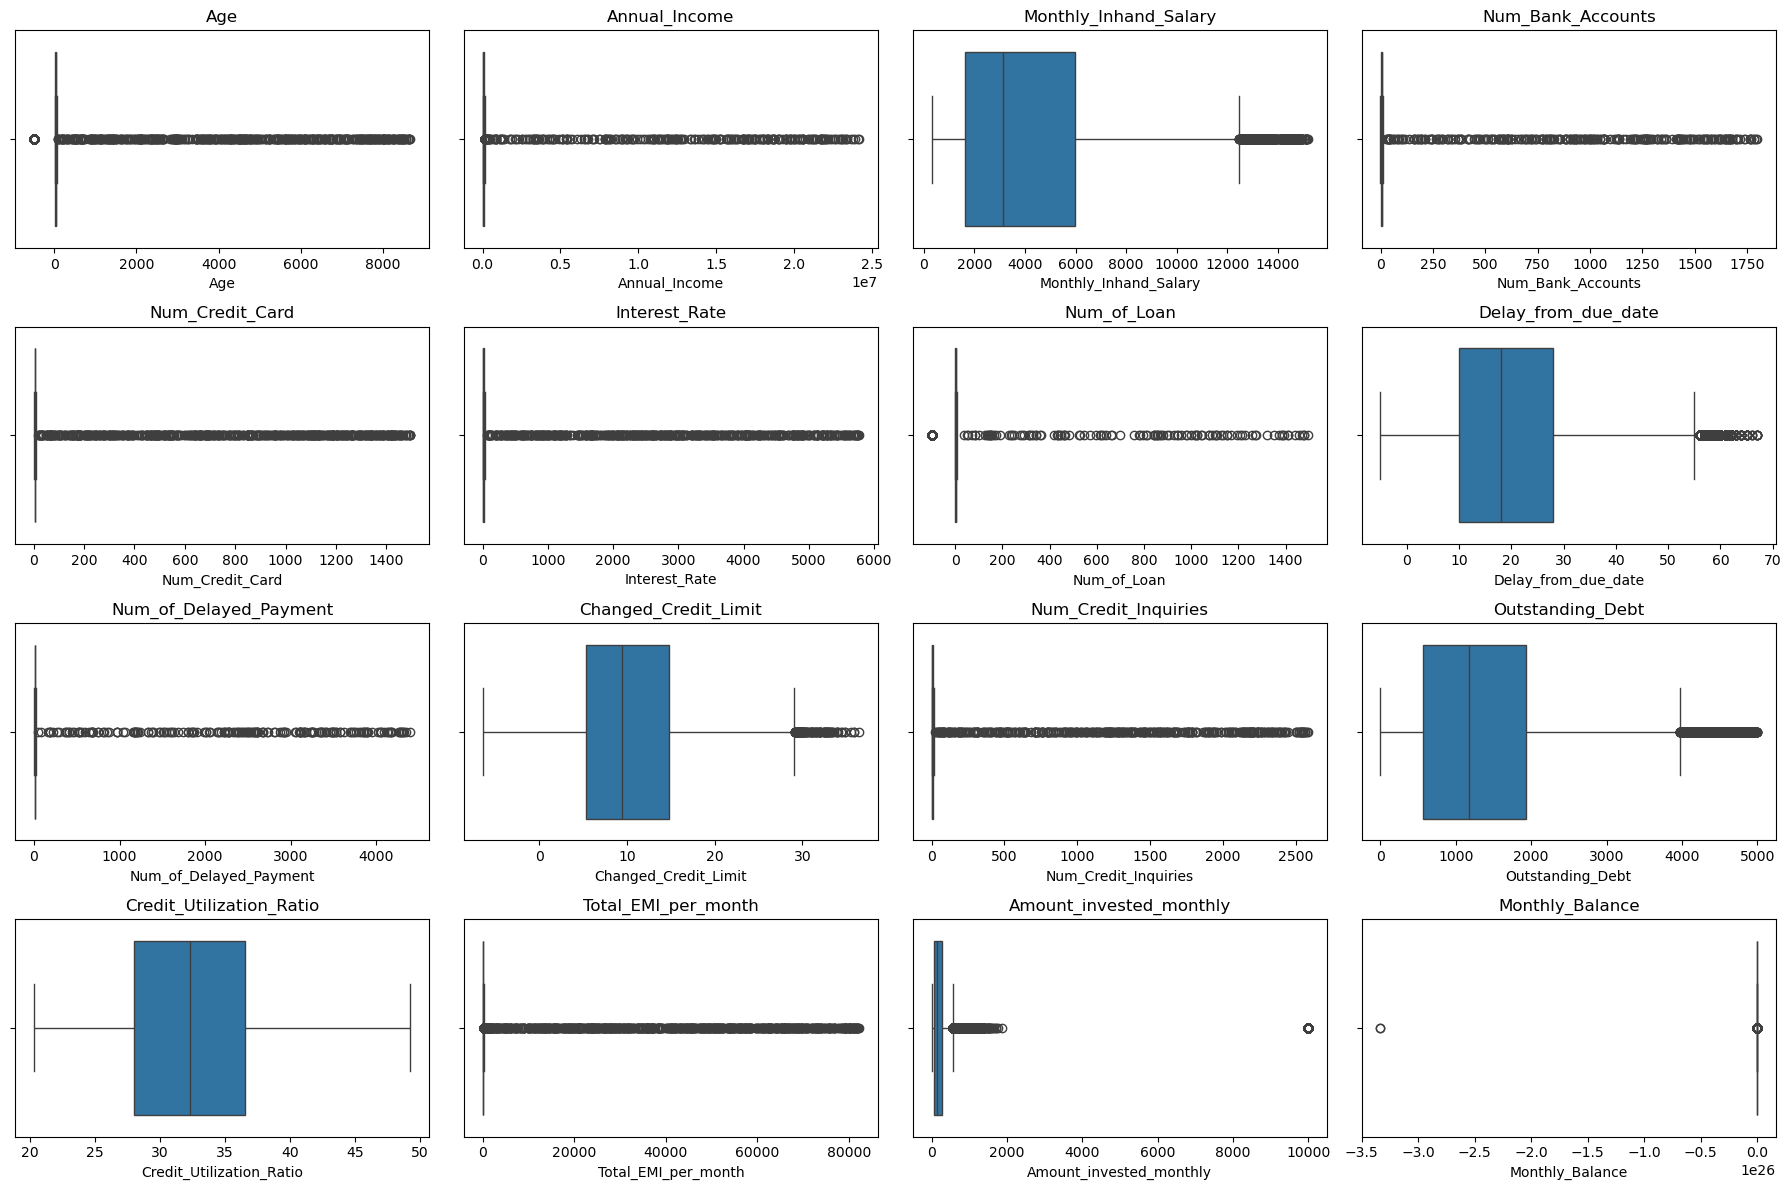

In [19]:
fig, axes = plt.subplots(4, 4, figsize=(18,12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [20]:
df.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,25000.000000,2.500000e+04,21244.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,23267.000000,24468.000000,24510.000000,25000.000000,25000.000000,25000.000000,23940.000000,2.469900e+04
mean,117.090440,1.848748e+05,4202.920107,16.189320,22.204800,72.883720,2.876120,21.029360,33.100056,10.364320,27.477111,1418.369978,32.294362,1300.578910,658.626924,-2.699165e+22
std,716.795846,1.481741e+06,3167.562787,113.979946,128.635884,464.533619,61.879436,14.815959,242.523318,6.774746,191.841035,1145.176915,5.136061,7938.267492,2087.136986,2.999475e+24
min,-500.000000,7.006035e+03,303.645417,-1.000000,0.000000,1.000000,-100.000000,-5.000000,-3.000000,-6.490000,0.000000,0.230000,20.257073,0.000000,0.000000,-3.333333e+26
25%,24.000000,1.954887e+04,1634.214792,3.000000,4.000000,8.000000,1.000000,10.000000,9.000000,5.320000,3.000000,563.310000,28.007510,30.622965,75.975894,2.694344e+02
50%,33.000000,3.782496e+04,3118.399167,6.000000,5.000000,13.000000,3.000000,18.000000,14.000000,9.370000,6.000000,1170.255000,32.276799,69.528976,138.572608,3.366188e+02
75%,42.000000,7.302054e+04,5968.797083,7.000000,7.000000,20.000000,5.000000,28.000000,18.000000,14.830000,9.000000,1925.940000,36.553116,161.078485,268.752901,4.717960e+02
max,8666.000000,2.417715e+07,15204.633333,1798.000000,1495.000000,5774.000000,1496.000000,67.000000,4397.000000,36.490000,2587.000000,4998.070000,49.254983,82256.000000,10000.000000,1.576289e+03


Berdasarkan boxplot dan statistik deskriptif, sebagian besar variabel numerik menunjukkan keberadaan outlier dengan rentang nilai yang jauh dari mayoritas observasi. Beberapa outlier terindikasi sebagai data tidak valid, misalnya Age yang memiliki nilai minimum -500 dan maksimum 8.666 tahun, Num_Bank_Accounts hingga 1.798 rekening, Num_Credit_Card hingga 1.495 kartu, Interest_Rate hingga 5.774%, serta Num_of_Loan hingga 1.496 pinjaman. Nilai-nilai tersebut tidak realistis dalam konteks profil kredit individu sehingga perlu ditangani pada tahap preprocessing. Selain itu, ditemukan nilai negatif pada Delay_from_due_date, Num_of_Delayed_Payment, dan Changed_Credit_Limit yang juga mengindikasikan inkonsistensi data. Di sisi lain, beberapa nilai ekstrem seperti Outstanding_Debt, Amount_invested_monthly, dan Total_EMI_per_month masih mungkin merepresentasikan kondisi finansial tertentu sehingga tidak langsung dianggap sebagai kesalahan data. Oleh karena itu, penanganan outlier dilakukan secara selektif dengan menetapkan batas valid berdasarkan domain bisnis untuk mengubah nilai yang tidak masuk akal menjadi missing value sebelum proses imputasi dilakukan.


## 4. Feature Engineering

### 4.1 Kategorikan kolom Type_of_Loan

In [21]:
df['Type_of_Loan'] = df['Type_of_Loan'].fillna('Unknown')

loan_dummies = (df['Type_of_Loan'].str.get_dummies(sep=', '))

df = pd.concat([df, loan_dummies], axis=1)
df.drop(columns=['Type_of_Loan'], inplace=True)

### 4.2 Ubah kolom Credit_History_Age menjadi satuan bulan

In [22]:
def convert_history(x):
    try:
        year = int(x.split(' ')[0])
        month = int(x.split(' ')[3])
        return year * 12 + month
    except:
        return np.nan

df['Credit_History_Age'] = df['Credit_History_Age'].apply(convert_history)

### 4.3 Encode Target

In [23]:
df['Credit_Score'] = df['Credit_Score'].map({'Poor': 0, 'Standard': 1, 'Good': 2})

## 5. Data Split

In [24]:
x = df.drop('Credit_Score', axis = 1)
y = df['Credit_Score']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print("x_train: ", x_train.shape)
print("x_test: ", x_test.shape)

x_train:  (20000, 32)
x_test:  (5000, 32)


## 6. Preprocessing

In [25]:
NUM_FEATURES = x.select_dtypes(include=['int64','float64']).columns.tolist()
CAT_FEATURES = x.select_dtypes(include='object').columns.tolist()

In [26]:
for col in CAT_FEATURES:
    print(f"\n{col}")
    print(x_train[col].value_counts(dropna=False))


Month
Month
March       2550
July        2541
August      2537
January     2520
April       2510
May         2458
June        2447
February    2437
Name: count, dtype: int64

Occupation
Occupation
NaN              1409
Accountant       1319
Lawyer           1307
Architect        1291
Engineer         1269
Scientist        1263
Media_Manager    1251
Writer           1242
Entrepreneur     1242
Doctor           1235
Mechanic         1230
Journalist       1201
Developer        1198
Manager          1192
Teacher          1188
Musician         1163
Name: count, dtype: int64

Credit_Mix
Credit_Mix
Standard    7268
Good        4854
NaN         4154
Bad         3724
Name: count, dtype: int64

Payment_of_Min_Amount
Payment_of_Min_Amount
Yes    10380
No      9620
Name: count, dtype: int64

Payment_Behaviour
Payment_Behaviour
Low_spent_Small_value_payments      5169
High_spent_Medium_value_payments    3568
Low_spent_Medium_value_payments     2756
High_spent_Large_value_payments     2727
High_spen

In [27]:
outlier_rules = {
    'Age': (18, 100),
    'Num_Bank_Accounts': (0, 50),
    'Num_Credit_Card': (0, 50),
    'Interest_Rate': (0, 100),
    'Num_of_Loan': (0, 50),
    'Delay_from_due_date': (0, 100),
    'Num_of_Delayed_Payment': (0, 100),
    'Changed_Credit_Limit' : (0, 50),
    'Num_Credit_Inquiries': (0, 100),
    'Monthly_Balance': (-1000000, 1000000)
}

In [28]:
def handle_invalid_values(df, rules):
    df = df.copy()

    for col, (lower, upper) in rules.items():
        if col in df.columns:
            df.loc[(df[col] < lower) | (df[col] > upper), col] = np.nan
    return df

x_train = handle_invalid_values(x_train, outlier_rules)
x_test = handle_invalid_values(x_test, outlier_rules)

In [29]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

ORDINAL_FEATURES = ['Credit_Mix', 'Payment_of_Min_Amount']
NOMINAL_FEATURES = ['Month', 'Occupation', 'Payment_Behaviour']

nominal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

ordinal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[
        ['Bad', 'Standard', 'Good'],
        ['No', 'Yes']
    ]))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, NUM_FEATURES),
    ('nom', nominal_transformer, NOMINAL_FEATURES),
    ('ord', ordinal_transformer, ORDINAL_FEATURES),
])

## 7. Modelling

### 7.1 Baseline Model

In [30]:
models = {
    'Logistic Regression': Pipeline([
        ('preprocessing', preprocessor),
        ('classifier', LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=42
        ))
    ]),

    'Random Forest': Pipeline([
        ('preprocessing', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=200,
            class_weight='balanced',
            random_state=42,
        ))
    ]),

    'Extra Trees': Pipeline([
        ('preprocessing', preprocessor),
        ('classifier', ExtraTreesClassifier(
            n_estimators=200,
            class_weight='balanced',
            random_state=42,
        ))
    ]),

    'Gradient Boosting': Pipeline([
        ('preprocessing', preprocessor),
        ('classifier', GradientBoostingClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]),

    'XGBoost': Pipeline([
        ('preprocessing', preprocessor),
        ('classifier', XGBClassifier(
            n_estimators=200,
            random_state=42,
            eval_metric='mlogloss'
        ))
    ])
}

In [31]:
results = {}
print("Hasil Evaluasi Model:\n")

for name, pipeline in models.items():
    pipeline.fit(x_train, y_train)
    y_pred = pipeline.predict(x_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')

    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'model': pipeline
    }

    print(
        f'{name:20s} | '
        f'Acc={acc:.4f} | '
        f'Prec={prec:.4f} | '
        f'Recall={rec:.4f} | '
        f'F1={f1:.4f}'
    )

Hasil Evaluasi Model:

Logistic Regression  | Acc=0.6358 | Prec=0.6276 | Recall=0.6849 | F1=0.6326
Random Forest        | Acc=0.7486 | Prec=0.7400 | Recall=0.7170 | F1=0.7272
Extra Trees          | Acc=0.7414 | Prec=0.7311 | Recall=0.7105 | F1=0.7198
Gradient Boosting    | Acc=0.7152 | Prec=0.6992 | Recall=0.6865 | F1=0.6920
XGBoost              | Acc=0.7376 | Prec=0.7266 | Recall=0.7081 | F1=0.7165


In [32]:
results_df = pd.DataFrame(results).T
results_df = results_df[['Accuracy', 'Precision', 'Recall', 'F1']].sort_values(by='F1', ascending=False)
results_df.head(3)

,Accuracy,Precision,Recall,F1
Random Forest,0.7486,0.740012,0.717023,0.727226
Extra Trees,0.7414,0.731102,0.710492,0.71975
XGBoost,0.7376,0.72658,0.708133,0.716509


### 7.2 Hyperparameter Tuning

In [48]:
param_grids = {
    'Random Forest': {
        'classifier__n_estimators': [200, 300, 400],
        'classifier__max_depth': [15, 20, 40],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4]
    },

    'Extra Trees': {
        'classifier__n_estimators': [200, 250, 300],
        'classifier__max_depth': [8, 12, 18],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4]
    },

    'XGBoost': {
        'classifier__n_estimators': [300, 500, 700],
        'classifier__max_depth': [4, 6, 8],
        'classifier__learning_rate': [0.01, 0.03, 0.05],
        'classifier__subsample': [0.8, 1.0],
        'classifier__colsample_bytree': [0.8, 1.0]
    }
}

top_models = {
    'Random Forest': models['Random Forest'],
    'Extra Trees': models['Extra Trees'],
    'XGBoost': models['XGBoost']
}
best_models = {}

for name, pipeline in top_models.items():
    print(f"\nTuning {name}")

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_grids[name],
        n_iter=20,
        cv=3,
        scoring='f1_macro',
        random_state=42,
        n_jobs=-1,
        verbose=1
    )

    search.fit(x_train, y_train)
    best_pipeline = search.best_estimator_
    y_pred = best_pipeline.predict(x_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')

    best_models[name] = {
        'Best Params': search.best_params_,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'Model': best_pipeline
    }

    print(f"Best Params : {search.best_params_}")
    print(f"Test F1     : {f1:.4f}")


Tuning Random Forest
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Params : {'classifier__n_estimators': 300, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 2, 'classifier__max_depth': 40}
Test F1     : 0.7290

Tuning Extra Trees
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Params : {'classifier__n_estimators': 250, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 1, 'classifier__max_depth': 18}
Test F1     : 0.7041

Tuning XGBoost
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Params : {'classifier__subsample': 0.8, 'classifier__n_estimators': 700, 'classifier__max_depth': 8, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 1.0}
Test F1     : 0.7346


In [49]:
tuning_results = pd.DataFrame(best_models).T
tuning_results = tuning_results[['Accuracy', 'Precision', 'Recall', 'F1']].sort_values(by='F1', ascending=False)
tuning_results

,Accuracy,Precision,Recall,F1
XGBoost,0.753,0.741827,0.72838,0.734642
Random Forest,0.7416,0.718806,0.746043,0.729009
Extra Trees,0.7144,0.692114,0.73522,0.704108


## 7.3 Confusion Matrix

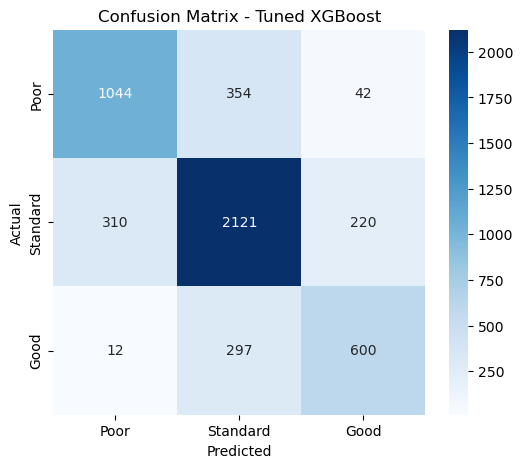

In [35]:
best_model_name = tuning_results.index[0]
best_model = best_models[best_model_name]['Model']
y_pred = best_model.predict(x_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Poor','Standard','Good'],
    yticklabels=['Poor','Standard','Good']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - Tuned {best_model_name}')
plt.show()

Confusion matrix menunjukkan bahwa model mampu mengklasifikasikan sebagian besar data dengan baik pada ketiga kelas credit score. Kelas Poor berhasil diprediksi dengan benar sebanyak 1.044 data, Standard sebanyak 2.121 data, dan Good sebanyak 600 data. Kesalahan prediksi paling sering terjadi pada kelas yang berdekatan, yaitu antara Poor dan Standard serta antara Standard dan Good, yang terlihat dari masih adanya data Poor yang diprediksi sebagai Standard (354 data) dan data Good yang diprediksi sebagai Standard (297 data). Hal ini menunjukkan bahwa model cukup baik dalam membedakan nasabah dengan profil kredit yang sangat berbeda, namun masih mengalami kesulitan ketika karakteristik nasabah berada pada batas antara dua kategori credit score yang berdekatan.

## 7.4 Feature Importance

In [36]:
best_model_name = tuning_results.index[0]
best_model = best_models[best_model_name]['Model']
feature_names = (best_model.named_steps['preprocessing'].get_feature_names_out())

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': best_model.named_steps['classifier'].feature_importances_
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)
print(importance_df.head(10))

                       Feature  Importance
56             ord__Credit_Mix    0.151039
57  ord__Payment_of_Min_Amount    0.095605
11       num__Outstanding_Debt    0.037148
5           num__Interest_Rate    0.026653
30          nom__Month_January    0.021059
29         nom__Month_February    0.020951
4         num__Num_Credit_Card    0.020709
3       num__Num_Bank_Accounts    0.019565
33            nom__Month_March    0.019486
7     num__Delay_from_due_date    0.015338


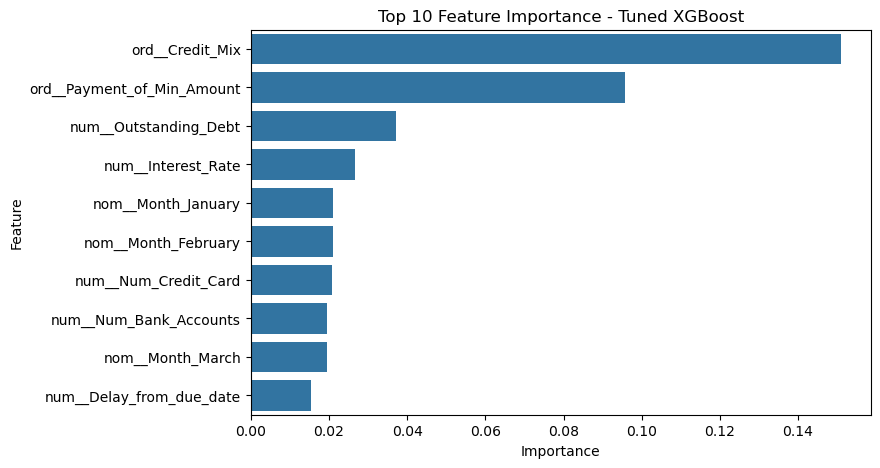

In [37]:
top10 = importance_df.head(10)

plt.figure(figsize=(8,5))
sns.barplot(data=top10, x='Importance', y='Feature')
plt.title(f'Top 10 Feature Importance - Tuned {best_model_name}')
plt.show()

Berdasarkan hasil feature importance, fitur yang paling berpengaruh dalam memprediksi credit score adalah Credit Mix (0.151) dan Payment of Minimum Amount (0.096), yang menunjukkan bahwa komposisi kredit yang dimiliki serta konsistensi pembayaran minimum merupakan faktor utama dalam penentuan skor kredit. Selain itu, variabel keuangan seperti Outstanding Debt (0.037), Interest Rate (0.027), dan Delay from Due Date (0.015) juga memberikan kontribusi yang cukup besar, mengindikasikan bahwa tingkat utang, bunga kredit, dan keterlambatan pembayaran berperan penting dalam menilai kelayakan kredit nasabah. Beberapa fitur lain seperti jumlah kartu kredit, jumlah rekening bank, serta kategori bulan tertentu juga muncul sebagai faktor yang berpengaruh, meskipun dampaknya relatif lebih kecil dibandingkan faktor yang secara langsung berkaitan dengan kondisi dan perilaku keuangan nasabah.